# Preprocessing - MFCC Feature Extraction

Bu notebook veri setindeki ses dosyalarından 3 saniyelik segmentler halinde MFCC özellikleri çıkarır ve `dataset/features_3.0_sec.json` dosyasını üretir.

In [1]:
from pathlib import Path
import json
import math

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import scipy.fft

GENRES = [
    "blues", "classical", "country", "disco", "hiphop",
    "jazz", "metal", "pop", "reggae", "rock",
]


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "dataset" / "genres_original").exists():
            return candidate
    raise FileNotFoundError("Proje kökü bulunamadı. Notebook'u music-genre-classification içinde çalıştırın.")

PROJECT_ROOT = find_project_root()
DATASET_DIR = PROJECT_ROOT / "dataset" / "genres_original"
FEATURES_PATH = PROJECT_ROOT / "dataset" / "features_3.0_sec.json"

print(f"Proje kökü: {PROJECT_ROOT}")
print(f"Veri seti: {DATASET_DIR}")
print(f"Çıktı JSON: {FEATURES_PATH}")

Proje kökü: C:\Users\Muham\Desktop\Data (1)\music-genre-classification
Veri seti: C:\Users\Muham\Desktop\Data (1)\music-genre-classification\dataset\genres_original
Çıktı JSON: C:\Users\Muham\Desktop\Data (1)\music-genre-classification\dataset\features_3.0_sec.json


In [2]:
for genre in GENRES:
    genre_dir = DATASET_DIR / genre
    wav_count = len(list(genre_dir.glob("*.wav"))) if genre_dir.exists() else 0
    print(f"Tür: {genre:10s} | Parça adedi: {wav_count}")

missing = [genre for genre in GENRES if not (DATASET_DIR / genre).exists()]
if missing:
    raise FileNotFoundError(f"Eksik tür klasörleri: {missing}")

Tür: blues      | Parça adedi: 100
Tür: classical  | Parça adedi: 100
Tür: country    | Parça adedi: 100
Tür: disco      | Parça adedi: 100
Tür: hiphop     | Parça adedi: 100
Tür: jazz       | Parça adedi: 100
Tür: metal      | Parça adedi: 100
Tür: pop        | Parça adedi: 100
Tür: reggae     | Parça adedi: 100
Tür: rock       | Parça adedi: 100


## Örnek Görselleştirme

Bu bölüm eğitim için zorunlu değildir; veri setinin doğru okunduğunu göstermek için örnek ses dalga formu, mel spectrogram ve MFCC görselleştirmesi üretir.

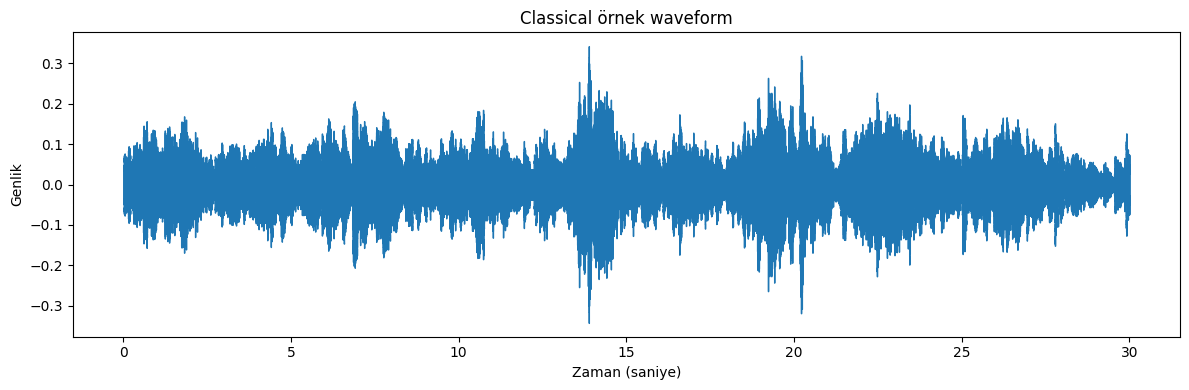

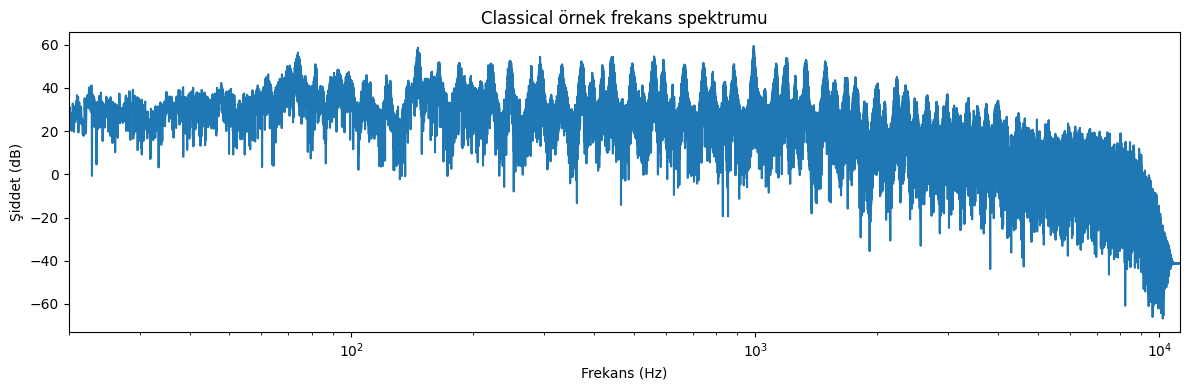

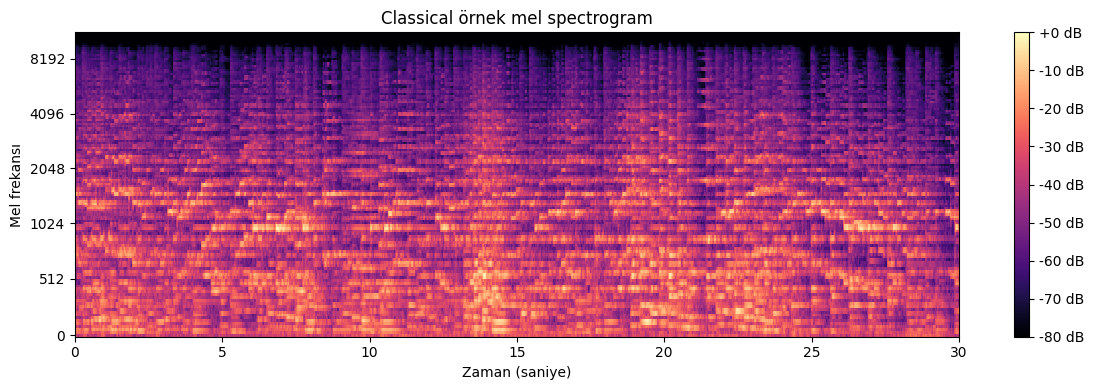

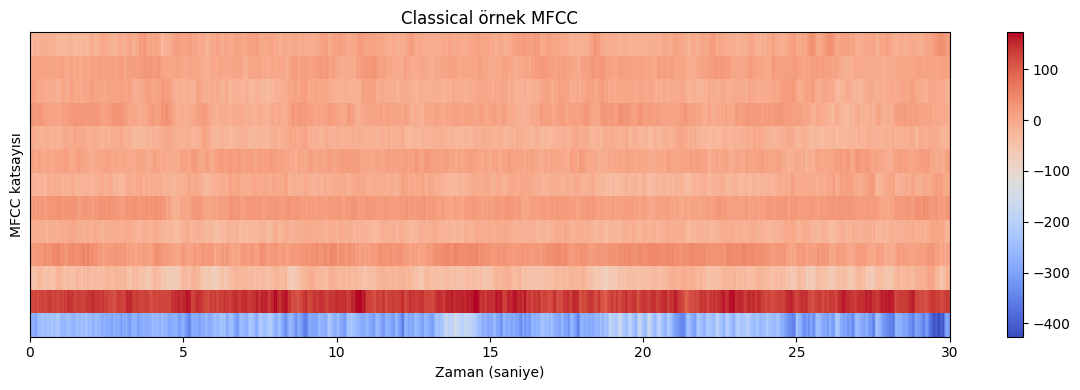

In [3]:
def waveform_plot(audio, sr, title):
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(audio, sr=sr)
    plt.title(title)
    plt.xlabel("Zaman (saniye)")
    plt.ylabel("Genlik")
    plt.tight_layout()
    plt.show()


def freq_spectrum_plot(audio, sr, title):
    spec = scipy.fft.fft(x=audio)
    spec_db = 20 * np.log10(np.maximum(np.abs(spec), 1e-10))
    f_axis = np.linspace(0, sr, len(spec_db))
    half = len(spec_db) // 2

    plt.figure(figsize=(12, 4))
    plt.plot(f_axis[:half], spec_db[:half])
    plt.xscale("log")
    plt.xlim(20, sr / 2)
    plt.title(title)
    plt.xlabel("Frekans (Hz)")
    plt.ylabel("Şiddet (dB)")
    plt.tight_layout()
    plt.show()


def mel_spectrogram_plot(audio, sr, title):
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(mel_db, sr=sr, hop_length=512, x_axis="time", y_axis="mel")
    plt.colorbar(format="%+2.0f dB")
    plt.title(title)
    plt.xlabel("Zaman (saniye)")
    plt.ylabel("Mel frekansı")
    plt.tight_layout()
    plt.show()


def mfcc_plot(audio, sr, title):
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_fft=2048, hop_length=512, n_mfcc=13)

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(mfcc, sr=sr, hop_length=512, x_axis="time")
    plt.colorbar()
    plt.title(title)
    plt.xlabel("Zaman (saniye)")
    plt.ylabel("MFCC katsayısı")
    plt.tight_layout()
    plt.show()


sample_track = DATASET_DIR / "classical" / "classical.00000.wav"
audio_ex, sr_ex = librosa.load(sample_track, sr=22500)
waveform_plot(audio_ex, sr_ex, "Classical örnek waveform")
freq_spectrum_plot(audio_ex, sr_ex, "Classical örnek frekans spektrumu")
mel_spectrogram_plot(audio_ex, sr_ex, "Classical örnek mel spectrogram")
mfcc_plot(audio_ex, sr_ex, "Classical örnek MFCC")

## MFCC Çıkarma

Model eğitiminde 30 saniyelik her parça 10 parçaya bölünür. Böylece her örnek yaklaşık 3 saniyelik bir segment olur.

In [ ]:
def extract_mfccs(
    dataset_dir: Path,
    output_path: Path,
    sample_rate: int = 22500,
    track_duration: int = 30,
    n_fft: int = 2048,
    hop_length: int = 512,
    n_mfcc: int = 13,
    num_segments: int = 10,
) -> dict:
    data = {
        "mapping": GENRES,
        "genre_name": [],
        "genre_num": [],
        "file": [],
        "segment": [],
        "mfcc": [],
    }

    samples_per_track = sample_rate * track_duration
    samples_per_segment = samples_per_track // num_segments
    expected_mfcc_vectors = math.ceil(samples_per_segment / hop_length)

    print("MFCC çıkarma başladı")
    print("=======================")

    for genre_index, genre in enumerate(GENRES):
        genre_dir = dataset_dir / genre
        print(f"{genre.title()} işleniyor...")

        for file_path in sorted(genre_dir.glob("*.wav")):
            try:
                signal, sr = librosa.load(file_path, sr=sample_rate, duration=track_duration)

                for segment_index in range(num_segments):
                    start_sample = segment_index * samples_per_segment
                    end_sample = start_sample + samples_per_segment
                    segment = signal[start_sample:end_sample]

                    if len(segment) < samples_per_segment:
                        segment = np.pad(segment, (0, samples_per_segment - len(segment)))

                    mfcc = librosa.feature.mfcc(
                        y=segment,
                        sr=sr,
                        n_fft=n_fft,
                        hop_length=hop_length,
                        n_mfcc=n_mfcc,
                    ).T

                    if len(mfcc) == expected_mfcc_vectors:
                        data["genre_name"].append(genre)
                        data["genre_num"].append(genre_index)
                        data["file"].append(str(file_path.relative_to(dataset_dir)))
                        data["segment"].append(segment_index)
                        data["mfcc"].append(mfcc.tolist())
            except Exception as exc:
                print(f"Atlandı: {file_path.name} -> {exc}")

    output_path.parent.mkdir(parents=True, exist_ok=True)
    with output_path.open("w", encoding="utf-8") as fp:
        json.dump(data, fp, indent=2)

    print("=======================")
    print(f"Kaydedildi: {output_path}")
    print(f"Toplam segment: {len(data['mfcc'])}")
    return data

In [ ]:
features = extract_mfccs(
    dataset_dir=DATASET_DIR,
    output_path=FEATURES_PATH,
    sample_rate=22500,
    track_duration=30,
    n_fft=2048,
    hop_length=512,
    n_mfcc=13,
    num_segments=10,
)

X_preview = np.array(features["mfcc"])
y_preview = np.array(features["genre_num"])
print(f"MFCC shape: {X_preview.shape}")
print(f"Label shape: {y_preview.shape}")